In [1]:
!pip install facenet-pytorch

In [2]:

# libraries
import numpy as np
from facenet_pytorch import MTCNN
import cv2
import os

c:\Users\ahmed\anaconda3\envs\tensor\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


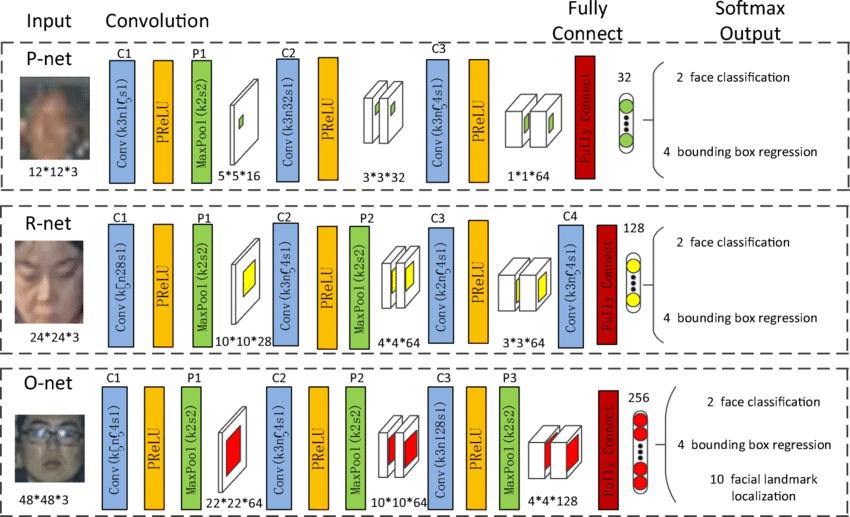

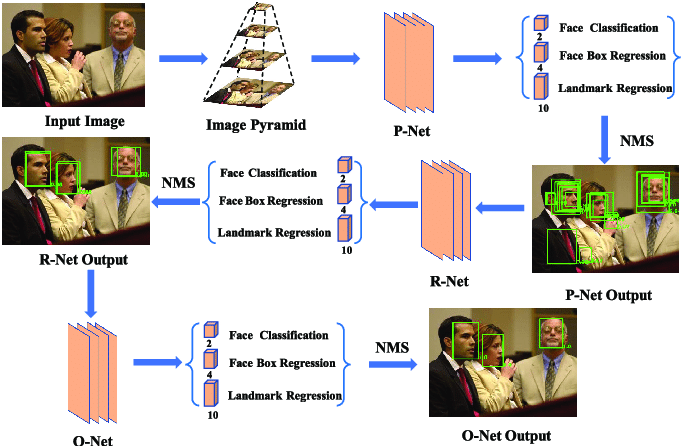

In [3]:
mtcnn = MTCNN(image_size=160, margin=15, min_face_size=20,device='cpu', post_process=True)

# image_size:
# This parameter specifies the desired size of the input image after resizing.
# The MTCNN model will resize the input image to this size before processing.
# A common value is 160, which balances accuracy and computational efficiency.

# margin:
# The margin parameter controls the extra padding around the detected face bounding box.
# It ensures that the entire face (including some background) is included in the cropped face image.
# A larger margin provides more context around the face but may include non-face regions.

# post_process:
# When post_process is set to True, the MTCNN model performs additional post-processing steps.
# These steps include non-maximum suppression (NMS) to remove duplicate detections and refine the bounding boxes.
# If set to False, the raw bounding boxes without post-processing are returned.

In [4]:
cap = cv2.VideoCapture(0) #Test Project.avi 
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
import os
count = 0
output = "Dataset/Ahmed"
os.makedirs(output,exist_ok=True)
skip = 0
while cap.isOpened() :

    ret, frame = cap.read()
    if not ret:
        break
    frame_BGR=frame.copy()
    if skip % 5 == 0 :
        frame=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        boxes, probs = mtcnn.detect(frame, landmarks=False)
        
        if  not probs.all() == None and probs.all() > 0.6 :
            for x1,y1,x2,y2 in boxes :
                x1,x2,y1,y2=int(x1),int(x2),int(y1),int(y2)
                ROI=frame_BGR[y1:y2,x1:x2]
                cv2.imwrite(f'{output}/img{count}.jpg', ROI)
                count = count + 1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 3)
                
        frame=cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
    skip += 1
    cv2.imshow("Project", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'): # if press q
        break

cap.release()
cv2.destroyAllWindows()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import glob as gb
from tqdm import tqdm
from tensorflow.keras.layers import ZeroPadding2D,Convolution2D, MaxPooling2D, Dropout, Flatten, Activation
from tensorflow.keras.models import Sequential ,load_model

In [21]:
trainpath = 'Dataset/'
new_size = 224    

X_train = []
y_train = []
i = 0

for folder in os.listdir(trainpath): 
    print('folder name is : ', folder)

    files = gb.glob(pathname=str(trainpath + folder + '/*.jpg'))
    print('numbers of images in folder are : ', len(files))
    print('start reading images')

    image_class = {folder: i}   # assign label for this folder

    for file in files:
        orignal_image = cv2.imread(file)
        image = cv2.cvtColor(orignal_image, cv2.COLOR_BGR2RGB)
        resized_image = cv2.resize(image, (new_size, new_size))

        X_train.append(resized_image)
        y_train.append(image_class[folder])

    i += 1   # increment AFTER finishing the folder
    print('image reading ...finished')

print('--------------------------------------------------')        
print("items in X_train is:", len(X_train), "items") 
print("items in y_train is:", len(y_train), "items")

folder name is :  Ahmed
numbers of images in folder are :  23
start reading images
image reading ...finished
--------------------------------------------------
items in X_train is: 23 items
items in y_train is: 23 items


In [22]:
X_train[0]

array([[[ 97,  96,  92],
        [ 97,  96,  92],
        [ 97,  96,  93],
        ...,
        [100,  99,  97],
        [100,  99,  97],
        [101, 100,  98]],

       [[ 98,  97,  93],
        [ 98,  97,  93],
        [ 98,  97,  94],
        ...,
        [100,  99,  97],
        [100,  99,  97],
        [101, 100,  98]],

       [[ 98,  97,  93],
        [ 98,  97,  93],
        [ 98,  97,  94],
        ...,
        [100,  99,  97],
        [101, 100,  98],
        [101,  99, 100]],

       ...,

       [[ 12,  12,  12],
        [ 12,  12,  12],
        [ 12,  12,  12],
        ...,
        [ 14,  14,  14],
        [ 14,  14,  14],
        [ 14,  14,  14]],

       [[ 12,  12,  12],
        [ 12,  12,  12],
        [ 12,  12,  12],
        ...,
        [ 13,  13,  13],
        [ 13,  13,  13],
        [ 14,  14,  14]],

       [[ 12,  12,  12],
        [ 12,  12,  12],
        [ 12,  12,  12],
        ...,
        [ 13,  13,  13],
        [ 14,  14,  14],
        [ 15,  15,  15]]

In [8]:
y_train[0]

0

In [9]:
y_train

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

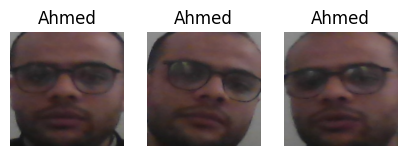

In [23]:
#showing training images with labels

plt.figure(figsize=(5,5))
for n , i in enumerate(list(np.random.randint(0,len(X_train ),3))) : 
    plt.subplot(1,3,n+1)
    plt.imshow(X_train[i])   
    classes = {'Ahmed': 0}
    def ImageClass(n):
        for x , y in classes.items():
            if n == y :
                return x
    plt.title(ImageClass(y_train[i]))
    plt.axis('off')
plt.show()

In [24]:
X_train=np.array(X_train)
y_train=np.array(y_train)

In [25]:
#shuffle data
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train)

In [26]:
#normalizing data
X_train=X_train/255.0

In [27]:
from tensorflow.keras.layers import Input, ZeroPadding2D, Conv2D, MaxPooling2D, Dropout, Flatten, Activation
from tensorflow.keras.models import Model, Sequential

def vgg_face():
    inp = Input(shape=(224, 224, 3))

    model = Sequential()
    model.add(inp)

    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(Conv2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Conv2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Conv2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation("softmax"))

    return model


https://github.com/serengil/deepface_models/releases/?utm_source=chatgpt.com

In [28]:
from tensorflow.keras.models import Model

model = vgg_face()
model.load_weights("vgg_face_weights.h5")

# Output of the layer before Flatten (the 2622 features)
embedding_model = Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

print(embedding_model.summary())


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 zero_padding2d_13 (ZeroPadd  (None, 226, 226, 3)      0         
 ing2D)                                                          
                                                                 
 conv2d_16 (Conv2D)          (None, 224, 224, 64)      1792      
                                                                 
 zero_padding2d_14 (ZeroPadd  (None, 226, 226, 64)     0         
 ing2D)                                                          
                                                                 
 conv2d_17 (Conv2D)          (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 112, 112, 64)     0   

In [29]:
embeddings = np.zeros((X_train.shape[0], 2622))
for i, m in enumerate(tqdm(X_train)):
    embedding_vector = model.predict(np.expand_dims(m, axis=0),verbose=0)[0]
    embeddings[i]=embedding_vector
    

100%|██████████| 23/23 [00:01<00:00, 11.79it/s]


In [30]:
embeddings[0].shape

(2622,)

In [18]:
embeddings.shape

(51, 2622)

In [19]:
y_train.shape

(51,)

In [31]:
# Reshape y_train to have one column
y_train_reshaped = y_train.astype(np.int32).reshape(-1, 1)
# Now concatenate embeddings and y_train_reshaped along axis 1 (columns)
w = np.concatenate((embeddings, y_train_reshaped), axis=1)

In [32]:
y_train_reshaped[:5]

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [33]:
w.shape

(23, 2623)

In [35]:
import pandas as pd
data=pd.DataFrame(w)

In [36]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,2613,2614,2615,2616,2617,2618,2619,2620,2621,2622
0,0.000387,0.000385,0.000384,0.000383,0.000384,0.000384,0.000382,0.000387,0.000385,0.000385,...,0.000380,0.000378,0.000383,0.000380,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
1,0.000388,0.000384,0.000384,0.000382,0.000383,0.000384,0.000380,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000380,0.000383,0.000379,0.000378,0.000385,0.000386,0.0
2,0.000387,0.000384,0.000383,0.000384,0.000383,0.000383,0.000382,0.000387,0.000385,0.000386,...,0.000379,0.000379,0.000383,0.000381,0.000382,0.000378,0.000379,0.000385,0.000385,0.0
3,0.000387,0.000384,0.000384,0.000383,0.000383,0.000384,0.000381,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
4,0.000388,0.000383,0.000385,0.000383,0.000384,0.000383,0.000380,0.000387,0.000385,0.000385,...,0.000381,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000385,0.000386,0.0


In [37]:
data.to_csv('Face Recognition.csv',index=None)

In [38]:
data.shape

(23, 2623)

In [39]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,2613,2614,2615,2616,2617,2618,2619,2620,2621,2622
0,0.000387,0.000385,0.000384,0.000383,0.000384,0.000384,0.000382,0.000387,0.000385,0.000385,...,0.000380,0.000378,0.000383,0.000380,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
1,0.000388,0.000384,0.000384,0.000382,0.000383,0.000384,0.000380,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000380,0.000383,0.000379,0.000378,0.000385,0.000386,0.0
2,0.000387,0.000384,0.000383,0.000384,0.000383,0.000383,0.000382,0.000387,0.000385,0.000386,...,0.000379,0.000379,0.000383,0.000381,0.000382,0.000378,0.000379,0.000385,0.000385,0.0
3,0.000387,0.000384,0.000384,0.000383,0.000383,0.000384,0.000381,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
4,0.000388,0.000383,0.000385,0.000383,0.000384,0.000383,0.000380,0.000387,0.000385,0.000385,...,0.000381,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000385,0.000386,0.0


## Cosine

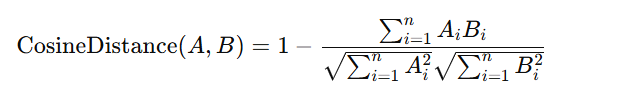

In [40]:
def findCosineSimilarity(source_representation, test_representation):
    a = np.matmul(np.transpose(source_representation), test_representation)
    b = np.sum(np.multiply(source_representation, source_representation))
    c = np.sum(np.multiply(test_representation, test_representation))
    return 1 - (a / (np.sqrt(b) * np.sqrt(c)))

In [41]:
import pandas as pd
data=pd.read_csv('Face Recognition.csv')

In [42]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,2613,2614,2615,2616,2617,2618,2619,2620,2621,2622
0,0.000387,0.000385,0.000384,0.000383,0.000384,0.000384,0.000382,0.000387,0.000385,0.000385,...,0.000380,0.000378,0.000383,0.000380,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
1,0.000388,0.000384,0.000384,0.000382,0.000383,0.000384,0.000380,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000380,0.000383,0.000379,0.000378,0.000385,0.000386,0.0
2,0.000387,0.000384,0.000383,0.000384,0.000383,0.000383,0.000382,0.000387,0.000385,0.000386,...,0.000379,0.000379,0.000383,0.000381,0.000382,0.000378,0.000379,0.000385,0.000385,0.0
3,0.000387,0.000384,0.000384,0.000383,0.000383,0.000384,0.000381,0.000387,0.000384,0.000385,...,0.000380,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000386,0.000387,0.0
4,0.000388,0.000383,0.000385,0.000383,0.000384,0.000383,0.000380,0.000387,0.000385,0.000385,...,0.000381,0.000378,0.000382,0.000381,0.000383,0.000378,0.000379,0.000385,0.000386,0.0


In [43]:
def MTCNN_to_Detections(faces, probs):
    """
    Convert MTCNN face detection outputs to Supervision's Detections format.

    Parameters:
    faces : list of lists/arrays
        Each element contains [x1, y1, x2, y2] coordinates of a detected face.
    probs : list
        List of confidence scores for each detected face.

    Returns:
    detections : sv.Detections
        Detections object containing bounding boxes, confidence scores, and class IDs.
    """
    detections = sv.Detections.empty()  # Initialize empty Detections object
    for face, prob in zip(faces, probs):
        # Create a bounding box array in the format [x1, y1, x2, y2]
        bounding_box = np.array([int(face[0]), int(face[1]), int(face[2]), int(face[3])], dtype=np.float32)
        
        # Append bounding box to the detections
        detections.xyxy = np.append(detections.xyxy, [bounding_box], axis=0)
        # Append corresponding confidence score
        detections.confidence = np.append(detections.confidence, prob)
        # Append class_id, here '0' as placeholder since all detections are faces
        detections.class_id = np.append(detections.class_id, 0)
        
    return detections


In [44]:
def pre_Processing(roi, model):
   
    # Resize the ROI to the input size expected by the model
    roi = cv2.resize(roi, dsize=(224, 224))
    # Normalize pixel values to range [0, 1]
    img = roi / 255.0
    # Predict the embedding vector
    embedding_vector = model.predict(np.expand_dims(img, axis=0))[0]
    return embedding_vector

In [45]:
def face_recognition(data, embedding_vector):
 
    classifier = ['Ahmed']  # List of known names corresponding to IDs
    for i in range(data.shape[0]):
        # Compute cosine similarity between input embedding and known embeddings
        sim = findCosineSimilarity(embedding_vector, data.iloc[i, :-1])
        print(sim)
        if sim < 0.3:  # Threshold for recognition
            name = classifier[int(data.iloc[i, -1])]
            break
    else:
        name = 'Unknown'
    return name


def TrackID_With_Recognition(tracker, detections, student_id, model, data):

    # Update tracker with the current detections
    detections = tracker.update_with_detections(detections)
    
    for tracker_id, box in zip(detections.tracker_id, detections.xyxy):
        x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        
        # Check if the tracker ID is new (not recognized yet)
        if tracker_id not in student_id:
            roi = frame[y1:y2, x1:x2]  # Extract face region
            embedding_vector = pre_Processing(roi, model)  # Get embedding
            student_id[tracker_id] = face_recognition(data, embedding_vector)  # Recognize face
            
    return student_id, detections


def draw_detection(frame, detections):
 
    for box, _, _, _, track_id, _ in detections:
        x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        
        # Draw bounding box around face
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        # Put tracker ID near the bottom-right corner of the box
        cv2.putText(frame, f'ID {track_id}', (x2, y2), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        # Put recognized name above the bounding box
        cv2.putText(frame, f'{student_id[track_id]}', (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        
    return frame

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import cv2
from facenet_pytorch import MTCNN
import torch
import supervision as sv

# Initialize tracker
tracker = sv.ByteTrack()

# Select device
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Use CPU if GPU memory is low
device = torch.device("cpu")  # temporarily force CPU
# Face detector
mtcnn = MTCNN(image_size=160, margin=14, min_face_size=20, post_process=False, device=device)

# Open camera
cap = cv2.VideoCapture(0)

student_id = {}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect faces
    faces, probs = mtcnn.detect(rgb, landmarks=False)

    detections = sv.Detections.empty()

    # Check if faces were detected and probabilities exist
    if faces is not None and probs is not None and len(faces) > 0 and np.max(probs) > 0.95:
        detections = MTCNN_to_Detections(faces, probs)

        # Track + Recognize
        student_id, detections = TrackID_With_Recognition(
            tracker, detections, student_id, model, data
        )


    # Draw boxes & IDs
    frame = draw_detection(frame, detections)

    # === Real-Time Display ===
    cv2.imshow("Real-Time Face Recognition", frame)

    # Exit key: q
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Clean exit (no destroyAllWindows)
cap.release()
cv2.waitKey(1)


1/1 [==============================] - 0s 32ms/step
3.843552720206311e-06


-1

: 

In [34]:
student_id

{1: 'Ahmed'}